# An autonomous NV-centre sensor: deviations from self-oscillation as the measurement signal

Demonstration for the work package "Use of deviations from autonomous behaviour as signals of external perturbations for quantum sensing devices", implemented on the existing CW ODMR setup (SMCV100B + Red Pitaya,
FM lock-in with virtual demodulation at a fixed 5 kHz, no phase reference).

## The idea in one paragraph

Our frequency-locked NV magnetometer is a dynamical system, whose oscillatory behaviour is determined by its gain. Consider the photoluminesence (PL) dip found at resonance. One way of setting up a magnetometer would be to obtain the slope of the PL dips, and "park" the microwave frequency there. Then, on each subsequent measurement, any PL devitation detected by the photodiode is considered as a change in background magnetic field. The microwave frequency is then updated to account for this change in PL, giving us a new frequency `f_{k+1}`. Each lock cycle applies the discrete map `f_{k+1} = f_k − (G/D_cal)·[R(f_k) − R_0]`, whose linearisation has multiplier `1 − G_eff` with the dimensionless gain `G_eff = G·D_true/D_cal` proportional to the local slope of the ODMR lock-in lobe. For `G_eff < 2` the loop is an ordinary tracker; at `G_eff = 2` it undergoes a **flip (period-doubling) bifurcation** and
becomes a **self-oscillator** — a limit cycle generated entirely by the device, with no external clock or drive, cascading to chaos at higher gain (fig. 2). The
device's *deviation from* or *onset of* autonomous behaviour is then used as the sensor output, in direct analogy with the proposal's programme: what the Josephson bifurcation amplifier does for superconducting circuits, this loop does for a room-temperature spin ensemble.

## What is sensed, and by which observable

| Observable of the autonomous device | Physical quantity it senses | Why |
|---|---|---|
| Mean of the locked/oscillating orbit | Uniform magnetic field (DC) | Shift symmetry: a uniform field only translates the resonance; the loop re-centres. Ordinary magnetometry survives. |
| **Onset of self-oscillation** (critical gain G_c) | **Slope-changing perturbations**: field **gradients** across the ensemble (inhomogeneous broadening), MW/laser power, temperature/linewidth | G_c = 2·D_cal/D_true; anything that reshapes the line moves the threshold (figs. 3, 4). A *differential* quantity, separated by symmetry from the uniform field — the NV analogue of the proposal's multi-weak-link gradient sensing. |
| Critical fluctuations below onset | Same as above, continuously | Loop noise gain diverges as 1/√(2 − G_eff): the fluctuation level is a precursor "susceptibility" measurement. |
| **Limit-cycle statistics** (cycle-amplitude envelope, two-time correlations) | **Time-periodic fields** above the loop bandwidth | The period-2 cycle acts as an *internal local oscillator*: an applied AC field appears as a mixing sideband in the demodulated cycle spectrum (fig. 5) — detected through second-order statistics, exactly the "two-time / n-time distribution functions" route of the proposal. |

## Correspondence with the proposal text

* *"Deviations from autonomous behaviour as signals of external perturbations"* —
  realised literally: the sensor output is the change in the loop's dynamical
  state (fixed point ↔ limit cycle ↔ chaos), not a calibrated analog voltage.
* *"The onset of the self-oscillating regime could be made dependent on a
  specific offset"* — the critical gain is set by the lobe slope; biasing G just
  below/above 2 makes the oscillation onset conditional on a chosen perturbation
  strength (fig. 4: a sharp P(oscillation) discriminator under realistic noise).
* *"Higher order statistical quantities such as the two-time or n-time
  distribution functions"* — periodic signals are read out from the two-time
  statistics of the limit cycle (fig. 5); the same analysis applies unchanged to
  the electron-emission statistics of the autonomous single-electron source.
* *"Differential quantities such as magnetic field gradients"* — by symmetry the
  threshold observable is blind to uniform fields and responds to gradients and
  other line-reshaping perturbations, mirroring the multi-weak-link Josephson
  refrigerator proposal.
* *"Comparison with NV centres"* — this demo **is** the NV benchmark platform,
  running today; every observable proposed for the SES/Josephson devices has a
  measured NV counterpart to compare against.

# Simulation
Here we simulate the system's behaviour, illustrating the effect of the opearting gain on the steady state frequency of the microwave generator.

In [11]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(11)

# Parameters
HW      = 0.75        # ODMR half-width Gamma/2 [MHz]
RPK     = 0.010       # FM lobe peak [V] (as on the rig, ~10 mV)
SIG_R   = 3e-4        # readout noise per cycle [V] (~3 % of peak)
DT      = 0.05        # loop cycle time [s] (~20 cycles/s on the rig)
CLIP    = 8.0         # actuator range [MHz] (sweep-span clip)


def lobe(x, beta=0.0):
    """FM lock-in lobe |dL/df| for a Lorentzian of fixed contrast whose width
    is broadened by (1+beta). Positive x = detuning from the line centre."""
    hw = HW * (1.0 + beta)
    s = 2 * hw**2 * np.abs(x) / (x**2 + hw**2) ** 2
    s0 = 2 * HW**2 * (HW / np.sqrt(3)) / ((HW**2 / 3 + HW**2) ** 2)  # peak, beta=0
    return RPK * s / s0


# ---- calibration (done once, at beta = 0, like the real script) ----------
_xg = np.linspace(HW / np.sqrt(3), 6 * HW, 4000)          # outer flank
X0 = float(_xg[np.argmin(np.abs(lobe(_xg) - 0.45 * RPK))])  # setpoint: 45 % of peak
R0 = float(lobe(X0))
_d = 1e-5
D_CAL = float((lobe(X0 + _d) - lobe(X0 - _d)) / (2 * _d))   # V/MHz (<0)


def step(u, G, beta=0.0, noise=0.0):
    """One loop cycle: u is the detuning f - c."""
    R = lobe(u, beta) + noise
    return u - (G / D_CAL) * (R - R0)


def orbit(G, n=400, beta=0.0, sigma=0.0, u0=X0 + 0.05, rng=rng, drift=None):
    # note: u0 is seeded slightly OFF the fixed point, so an unstable lock
    # actually departs even in the noise-free (deterministic) runs
    """Iterate the map; returns the detuning trace. `drift` = per-step line-
    centre displacement array (enters as an equivalent detuning kick)."""
    u = np.empty(n)
    u[0] = u0
    for k in range(1, n):
        nz = sigma * rng.standard_normal() if sigma else 0.0
        u[k] = step(u[k - 1], G, beta, nz)
        if drift is not None:
            u[k] -= drift[k] - drift[k - 1]
        u[k] = np.clip(u[k], -CLIP, CLIP)
    return u


def orbit_amp(G, beta=0.0, sigma=0.0, n=600, keep=200, rng=rng):
    """Steady-state oscillation amplitude (std of the tail of the orbit)."""
    return float(np.std(orbit(G, n, beta, sigma, rng=rng)[-keep:]))

## Figures

C:\Users\Gonzalo\AppData\Local\Temp\ipykernel_9440\731373182.py:37: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


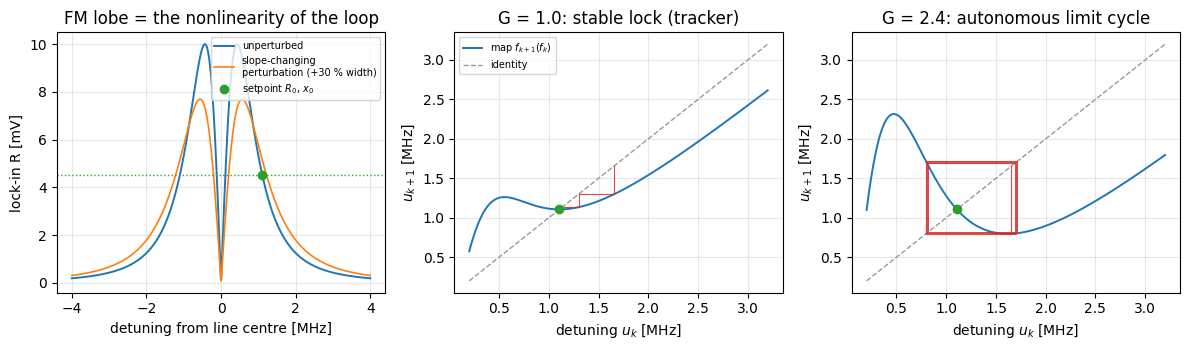

In [12]:
def cobweb(ax, G, n=40, u0=None):
    xs = np.linspace(0.2, 3.2, 600)
    ax.plot(xs, [step(x, G) for x in xs], color="C0", lw=1.4,
            label=r"map $f_{k+1}(f_k)$")
    ax.plot(xs, xs, color="0.6", lw=1, ls="--", label="identity")
    u = u0 if u0 is not None else X0 + 0.55
    px, py = [u], [u]
    for _ in range(n):
        v = step(u, G)
        px += [u, v]
        py += [v, v]
        u = v
    ax.plot(px, py, color="C3", lw=0.8, alpha=0.85)
    ax.plot(X0, X0, "o", color="C2", ms=6)
    ax.set(xlabel=r"detuning $u_k$ [MHz]", ylabel=r"$u_{k+1}$ [MHz]",
           title=f"loop gain G = {G}")
    ax.grid(alpha=0.3)


fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
x = np.linspace(-4, 4, 1200)
axes[0].plot(x, 1e3 * lobe(x), color="C0", lw=1.4, label="unperturbed")
axes[0].plot(x, 1e3 * lobe(x, 0.3), color="C1", lw=1.2,
             label="slope-changing\nperturbation (+30 % width)")
axes[0].axhline(1e3 * R0, color="C2", ls=":", lw=1)
axes[0].plot(X0, 1e3 * R0, "o", color="C2", label=rf"setpoint $R_0$, $x_0$")
axes[0].set(xlabel="detuning from line centre [MHz]", ylabel="lock-in R [mV]",
            title="FM lobe = the nonlinearity of the loop")
axes[0].legend(fontsize=7)
axes[0].grid(alpha=0.3)
cobweb(axes[1], 1.0)
axes[1].set_title("G = 1.0: stable lock (tracker)")
cobweb(axes[2], 2.4)
axes[2].set_title("G = 2.4: autonomous limit cycle")
axes[1].legend(fontsize=7)
fig.tight_layout()
fig.show()

## Steady state frequency dependence on gain

The following figure shows the onset of the self-sustained oscillation due to an increase in the sensor gain. This behaviour could yield a higher sensitivity for certain perturbations.

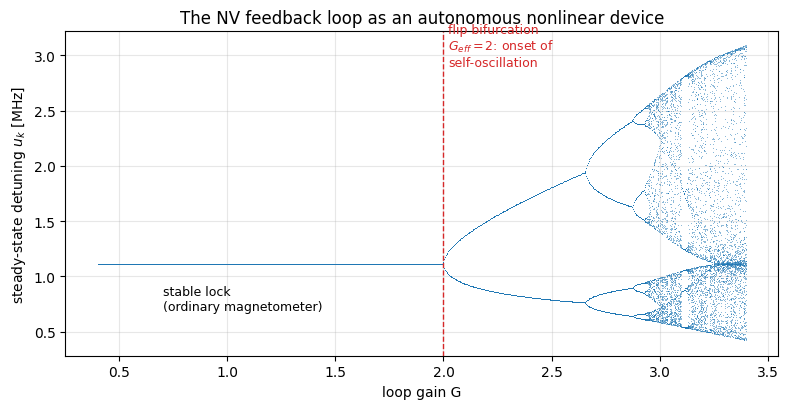

In [13]:
Gs = np.linspace(0.4, 3.4, 800)
fig, ax = plt.subplots(figsize=(8, 4.2))
for G in Gs:
    tail = orbit(G, 500)[-60:]
    ax.plot([G] * len(tail), tail, ",", color="C0", alpha=0.5)
ax.axvline(2.0, color="C3", ls="--", lw=1)
ax.annotate("flip bifurcation\n$G_{eff}=2$: onset of\nself-oscillation",
            (2.02, 2.9), color="C3", fontsize=9)
ax.annotate("stable lock\n(ordinary magnetometer)", (0.7, 0.7), fontsize=9)
ax.annotate("period doubling\n-> chaos", (2.75, 4.4), fontsize=9)
ax.set(xlabel="loop gain G", ylabel="steady-state detuning $u_k$ [MHz]",
       title="The NV feedback loop as an autonomous nonlinear device")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

# Gain tracks the influence of perturbations
The value of G for which the oscillatory behaviour appears is determined by external perturbation such as microwave power or background magnetic field magnitude. This figure shows the oscillation amplitude against G, for different linewidths of the PL resonance (left) and the gain at which the oscillaitons begin for each linewidth.

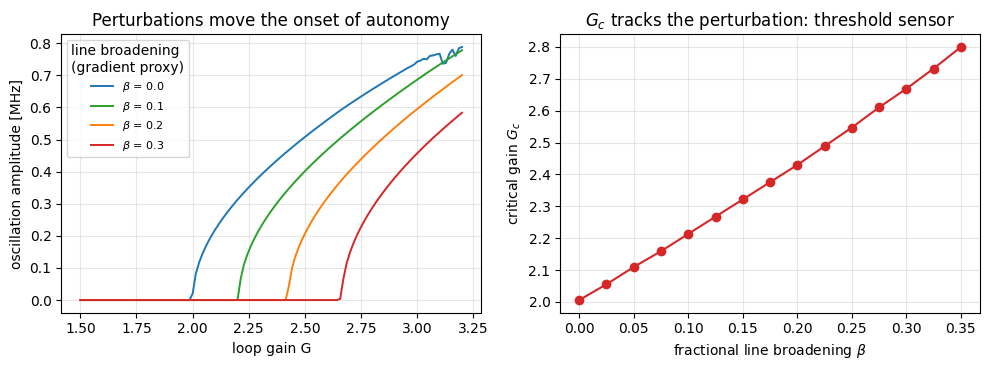

In [14]:
betas = (0.0, 0.1, 0.2, 0.3)
Gs3 = np.linspace(1.5, 3.2, 120)
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(10, 3.8))
for b, c in zip(betas, ("C0", "C2", "C1", "C3")):
    amp = [np.mean([orbit_amp(G, beta=b) for _ in range(1)]) for G in Gs3]
    ax.plot(Gs3, amp, color=c, lw=1.4, label=rf"$\beta$ = {b:.1f}")
ax.set(xlabel="loop gain G", ylabel="oscillation amplitude [MHz]",
       title="Perturbations move the onset of autonomy")
ax.legend(title="line broadening\n(gradient proxy)", fontsize=8)
ax.grid(alpha=0.3)

# threshold vs beta: smallest G with amplitude above a small cut
G_fine = np.linspace(1.6, 3.4, 400)
bet_fine = np.linspace(0, 0.35, 15)
thr = []
for b in bet_fine:
    a = np.array([orbit_amp(G, beta=b) for G in G_fine])
    idx = np.argmax(a > 0.05)
    thr.append(G_fine[idx] if a[idx] > 0.05 else np.nan)
ax2.plot(bet_fine, thr, "o-", color="C3")
ax2.set(xlabel=r"fractional line broadening $\beta$",
        ylabel="critical gain $G_c$",
        title=r"$G_c$ tracks the perturbation: threshold sensor")
ax2.grid(alpha=0.3)
fig.tight_layout()
plt.show()

# Experimental results

Using our setup, we performed an experiment to test some of these concepts. Plot A shows the change in the steady state frequency for different gain values. Highilighting the expected oscillatory behaviour of the sensor. Plot B then shows the orbit spread and coherent period-2 amplitude vs gain. Plot C shows example data obtained for different gains, showing how amplitude grows as expected. And lastly, plot D shows the demodulated cycle spectrum of the statistics run.



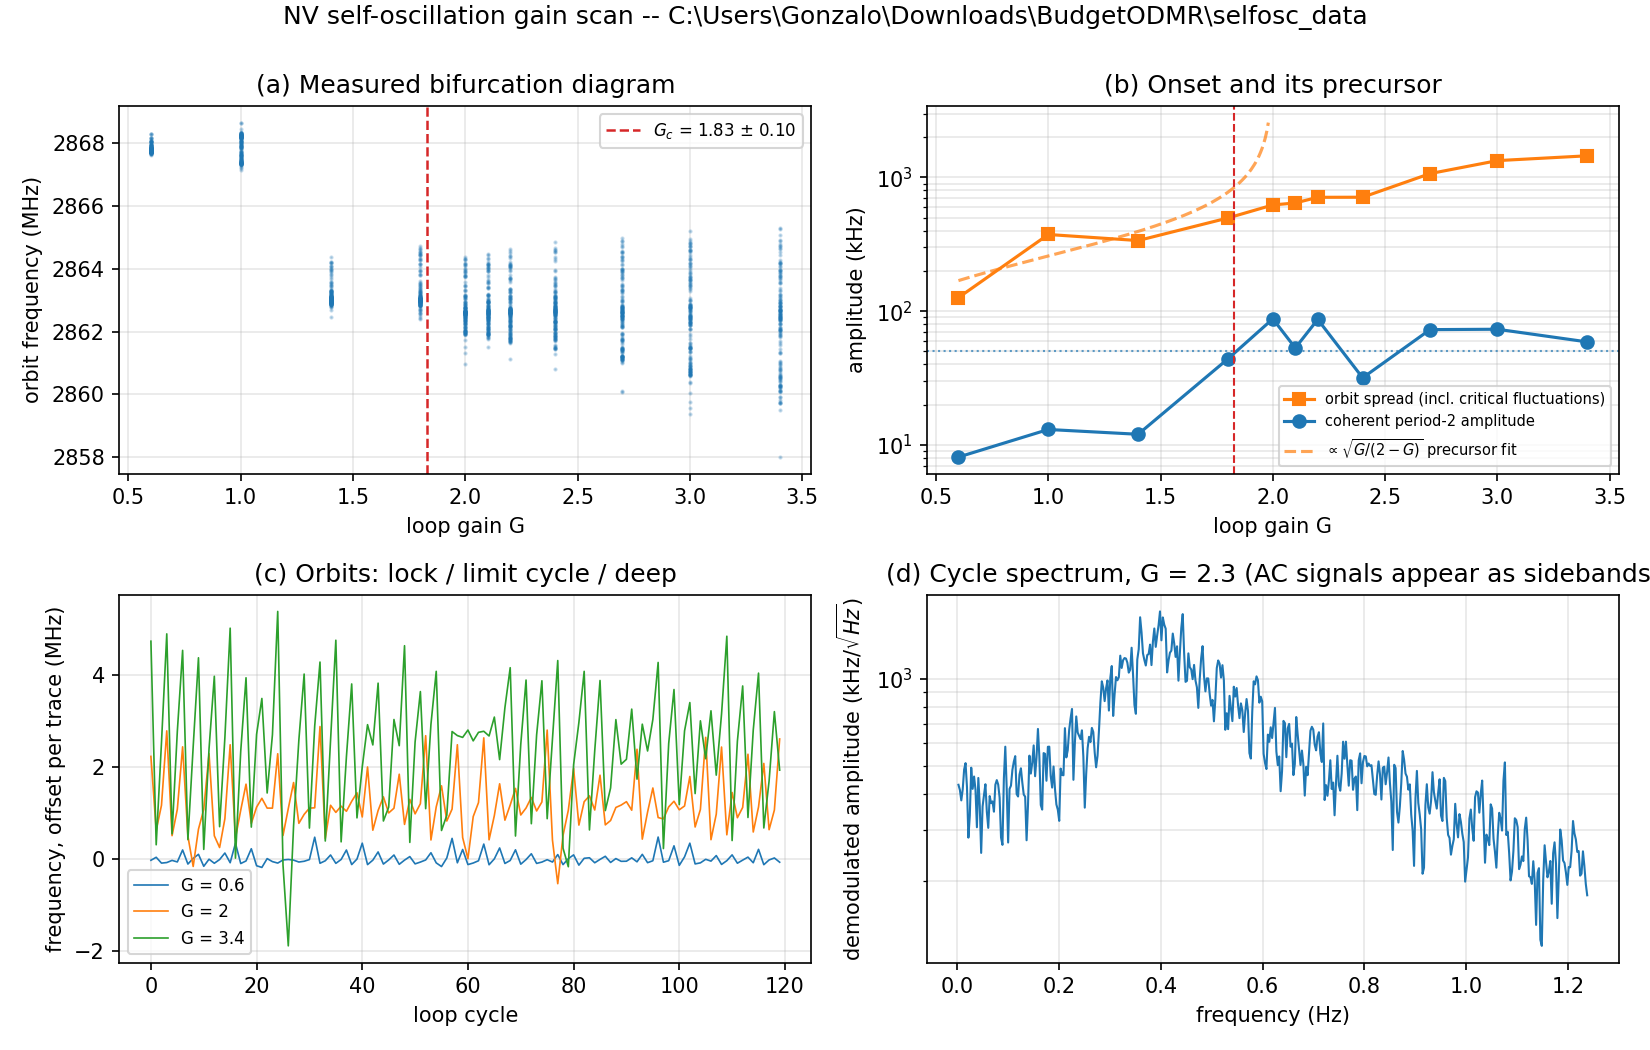

## Limitations

For Gaussian-noise-limited estimation of a *small analog* signal, a well-designed
linear readout with matched filtering is asymptotically optimal; the autonomous
mode does not beat it in raw SNR. Its advantages are of a different kind:
threshold/latching detection (binary output robust to gain and contrast drift),
symmetry-enforced selectivity to differential quantities, internal frequency
conversion of AC signals, and — scientifically — a table-top platform where the
sensing-through-bifurcation concepts of the proposal can be tested and
benchmarked against the same team's NV expertise before being deployed on
mesoscopic autonomous devices.
